# Bunna Bank HR Data — Final Project
Mahlet Sewinet Admasu, Ethiopia  
**GitHub:** https://github.com/mahisewinet/Kujenga-final-project  

## Research Question
What factors predict the current monthly salary of Bunna Bank employees, and does gender play a significant role after controlling for other variables?

## Data
This analysis is based on a random sample of Bunna Bank employees, not the full workforce. While random sampling reduces bias, the findings may still not fully represent the situation for all employees at the bank.

The dataset comes from Bunna Bank HR records and contains the following variables:
- **Sex** — gender of the employee (male or female)
- **YearsOfEducation** — total years of formal education completed
- **CurrentMonthlySalary** — the employee's current monthly salary in ETB (this is what we are trying to predict)
- **StartingMonthlySalary** — the monthly salary the employee received when they were first hired
- **MonthsAtBunnaBank** — how long the employee has been working at Bunna Bank, in months
- **PriorExperienceMonths** — work experience the employee had before joining Bunna Bank, in months

## Section 1 — Data Loading & Inspection

We start by loading the Bunna Bank HR dataset and inspecting its structure. This helps us understand what variables we are working with, their data types, and the overall shape of the data before any analysis begins.

In [87]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data/Bunna_bank_HR_data.csv')

# Display the first few rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,Sex,YearsOfEducation,CurrentMonthlySalary,StartingMonthlySalary,MonthsAtBunnaBank,PriorExperienceMonths
0,m,10,30000,15750,67,305
1,f,15,23850,13500,66,122
2,f,12,24000,13500,98,244
3,f,15,25200,13950,64,57
4,f,15,19200,9000,96,23


In [88]:
# Dataset shape
print(f'The dataset has {df.shape[0]} employees and {df.shape[1]} variables.')

The dataset has 374 employees and 6 variables.


In [89]:
# Data types and non-null counts
print('Dataset info:')
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Sex                    374 non-null    object
 1   YearsOfEducation       374 non-null    int64 
 2   CurrentMonthlySalary   374 non-null    int64 
 3   StartingMonthlySalary  374 non-null    int64 
 4   MonthsAtBunnaBank      374 non-null    int64 
 5   PriorExperienceMonths  374 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 17.7+ KB


All 374 employees have complete data across all 6 variables, with no missing values in the dataset.

In [90]:
# Summary statistics for all numeric columns
print('Summary statistics:')
df.describe()

Summary statistics:


,YearsOfEducation,CurrentMonthlySalary,StartingMonthlySalary,MonthsAtBunnaBank,PriorExperienceMonths
count,374.000000,374.000000,374.000000,374.000000,374.000000
mean,13.711230,33952.165775,16962.366310,81.467914,98.548128
std,2.437867,16650.609002,8166.849805,10.545079,104.004983
min,10.000000,15750.000000,9000.000000,63.000000,0.000000
25%,12.000000,24000.000000,12450.000000,72.000000,20.000000
50%,12.000000,28650.000000,15000.000000,81.000000,59.500000
75%,15.000000,36000.000000,17250.000000,90.000000,144.000000
max,21.000000,135000.000000,79980.000000,120.000000,476.000000


Current monthly salaries range from 15,750 to 135,000 ETB with a mean of 33,952 ETB, while starting salaries range from 9,000 to 79,980 ETB with a mean of 16,962 ETB. Employees have between 10 and 21 years of education (mean: 13.7) and have been at Bunna Bank between 63 and 120 months (mean: 81.5). Prior experience varies widely, from 0 to 476 months, with a mean of 98.5 months — suggesting a highly diverse workforce in terms of background.

In [91]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
Sex                      0
YearsOfEducation         0
CurrentMonthlySalary     0
StartingMonthlySalary    0
MonthsAtBunnaBank        0
PriorExperienceMonths    0
dtype: int64

Total missing values: 0


## Section 2 — Data Cleaning

Real-world data can contain duplicates, wrong data types, and extreme values (outliers) that can distort our analysis. In this section we check for all of these and prepare the data for analysis. We also encode the `Sex` variable as a number so it can be used in the regression model later.

In [92]:
# Step 1: Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


In [93]:
# Step 2: Confirm data types are correct
print('Data types:')
print(df.dtypes)

Data types:
Sex                      object
YearsOfEducation          int64
CurrentMonthlySalary      int64
StartingMonthlySalary     int64
MonthsAtBunnaBank         int64
PriorExperienceMonths     int64
dtype: object


All data types are correct. `Sex` is stored as text (object) and will be encoded as a numeric value later, while all other variables are stored as integers (int64), which is appropriate for this dataset.

In [94]:
# Step 3: Detect outliers using the IQR method for each numeric column
# An outlier is a value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR

numeric_cols = ['YearsOfEducation', 'CurrentMonthlySalary', 'StartingMonthlySalary',
                'MonthsAtBunnaBank', 'PriorExperienceMonths']

print('Outlier detection using IQR method:')
print('-' * 45)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}:')
    print(f'  Lower bound: {lower:.1f} | Upper bound: {upper:.1f}')
    print(f'  Outliers found: {len(outliers)}')

Outlier detection using IQR method:
---------------------------------------------
YearsOfEducation:
  Lower bound: 7.5 | Upper bound: 19.5
  Outliers found: 3
CurrentMonthlySalary:
  Lower bound: 6000.0 | Upper bound: 54000.0
  Outliers found: 48
StartingMonthlySalary:
  Lower bound: 5250.0 | Upper bound: 24450.0
  Outliers found: 48
MonthsAtBunnaBank:
  Lower bound: 45.0 | Upper bound: 117.0
  Outliers found: 2
PriorExperienceMonths:
  Lower bound: -166.0 | Upper bound: 330.0
  Outliers found: 19


We will keep the outliers in the dataset because they represent real employees with genuine salary or experience values. Removing them could hide important patterns, especially at the senior level where salaries are naturally higher.

In [95]:
# Step 4: Encode Sex as a numeric variable for use in the regression model
# f (Female) = 0, m (Male) = 1
df['Sex_num'] = df['Sex'].map({'f': 0, 'm': 1})

print('Sex encoding added (f=0, m=1):')
print(df[['Sex', 'Sex_num']].value_counts().sort_index())

Sex encoding added (f=0, m=1):
Sex  Sex_num
f    0          173
m    1          201
Name: count, dtype: int64


The dataset contains 173 female employees and 201 male employees, giving a total of 374 employees.

In [96]:
# Final cleaned dataset preview
print(f'Dataset is ready for analysis: {df.shape[0]} employees, {df.shape[1]} columns')
df.head()

Dataset is ready for analysis: 374 employees, 7 columns


,Sex,YearsOfEducation,CurrentMonthlySalary,StartingMonthlySalary,MonthsAtBunnaBank,PriorExperienceMonths,Sex_num
0,m,10,30000,15750,67,305,1
1,f,15,23850,13500,66,122,0
2,f,12,24000,13500,98,244,0
3,f,15,25200,13950,64,57,0
4,f,15,19200,9000,96,23,0


## Section 3 — Exploratory Data Analysis (EDA)

Before running formal statistical tests, we explore the data visually. This helps us build intuition about the distributions and spot any obvious patterns, particularly around salary differences between male and female employees. The insights here will guide our interpretation of the t-test in Section 4.

In [97]:
# Mean salary comparison by Sex
mean_salary = df.groupby('Sex')['CurrentMonthlySalary'].mean().round(2)
print('Mean CurrentMonthlySalary by Sex:')
print(mean_salary)
print(f'\nDifference (Male - Female): {mean_salary["m"] - mean_salary["f"]:.2f}')

Mean CurrentMonthlySalary by Sex:
Sex
f    25788.99
m    40978.18
Name: CurrentMonthlySalary, dtype: float64

Difference (Male - Female): 15189.19


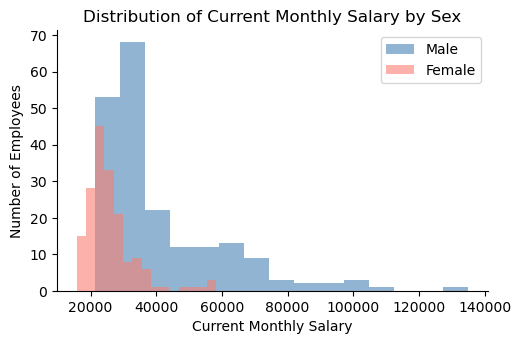

In [98]:
import matplotlib.pyplot as plt
# Overlapping histogram of CurrentMonthlySalary by Sex
# Same style as plot_runners.py from the course
male_salary = df[df['Sex'] == 'm']['CurrentMonthlySalary']
female_salary = df[df['Sex'] == 'f']['CurrentMonthlySalary']

fig, ax = plt.subplots(figsize=(9/2.54 * 1.5, 9/2.54))
ax.hist(male_salary, bins=15, alpha=0.6, label='Male', color='steelblue')
ax.hist(female_salary, bins=15, alpha=0.6, label='Female', color='salmon')
ax.set_xlabel('Current Monthly Salary')
ax.set_ylabel('Number of Employees')
ax.set_title('Distribution of Current Monthly Salary by Sex')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The histogram shows that female employees are concentrated at lower salary levels (mostly below 40,000 ETB), while male employees are more spread out across higher salary ranges, with a visible presence up to 140,000 ETB.

/tmp/ipykernel_11608/1885449483.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([female_data, male_data], labels=['Female', 'Male'], patch_artist=True,


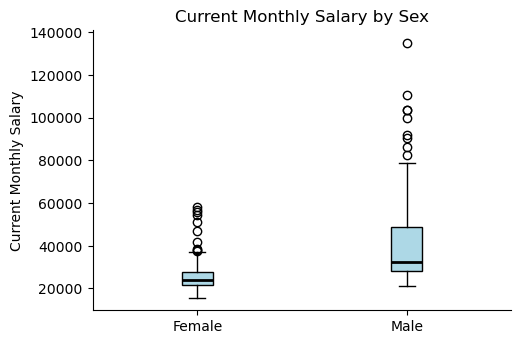

In [99]:
# Boxplot of CurrentMonthlySalary by Sex
fig, ax = plt.subplots(figsize=(9/2.54 * 1.5, 9/2.54))
male_data = df[df['Sex'] == 'm']['CurrentMonthlySalary']
female_data = df[df['Sex'] == 'f']['CurrentMonthlySalary']
ax.boxplot([female_data, male_data], labels=['Female', 'Male'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='black', linewidth=2))
ax.set_ylabel('Current Monthly Salary')
ax.set_title('Current Monthly Salary by Sex')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The boxplot confirms that male employees have a higher median salary and a much wider salary range than female employees, with male outliers reaching up to 140,000 ETB compared to around 60,000 ETB for females.

Both plots suggest a potential salary gap, confirmed formally by the t-test in Section 4.

## Section 4 — T-Test: Sex vs CurrentMonthlySalary

We want to know whether the salary difference between male and female employees is real or just due to chance. We use a two-sample t-test to answer this formally.

**Hypotheses:**
- H₀: μ_male = μ_female — there is no salary difference between male and female employees
- H₁: μ_male ≠ μ_female — there is a salary difference (two-sided test)

**Significance level:** α = 0.05

In [100]:
import numpy as np

# Separate salaries by Sex
male_sal = df[df['Sex'] == 'm']['CurrentMonthlySalary']
female_sal = df[df['Sex'] == 'f']['CurrentMonthlySalary']

# Group means and variances
n1, n2 = len(male_sal), len(female_sal)
mean1, mean2 = np.mean(male_sal), np.mean(female_sal)
var1, var2 = np.var(male_sal, ddof=1), np.var(female_sal, ddof=1)

print(f'Male   — n: {n1}, mean: {mean1:.2f}, variance: {var1:.2f}')
print(f'Female — n: {n2}, mean: {mean2:.2f}, variance: {var2:.2f}')

Male   — n: 201, mean: 40978.18, variance: 362773145.06
Female — n: 173, mean: 25788.99, variance: 54687762.20


In [101]:
from scipy.stats import ttest_ind

# Step 2: Run the t-test using scipy (same approach as in plot_runners.py)
t_stat, p_value = ttest_ind(male_sal, female_sal, alternative='two-sided', equal_var=False)

print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_value:.2e}')

T-statistic : 10.4296
P-value     : 1.39e-21


In [102]:
from scipy.stats import t

# Step 3: Compute the critical value
df_deg = n1 + n2 - 2
alpha = 0.05
critical_value = t.ppf(1 - alpha/2, df_deg)  # two-sided: split alpha across both tails

print(f'Degrees of freedom : {df_deg}')
print(f'Critical value (±) : {critical_value:.4f}')
print(f'Observed t-stat    : {t_stat:.4f}')

Degrees of freedom : 372
Critical value (±) : 1.9664
Observed t-stat    : 10.4296


In [103]:
# Step 4: Decision
print(f'P-value = {p_value:.2e} vs alpha = {alpha}')
if p_value < alpha:
    print('Decision: Reject H₀ — there is a statistically significant salary difference between male and female employees.')
else:
    print('Decision: Fail to reject H₀ — no statistically significant salary difference found.')

P-value = 1.39e-21 vs alpha = 0.05
Decision: Reject H₀ — there is a statistically significant salary difference between male and female employees.


The t-statistic of 10.43 is well above the critical value of ±1.97, and the p-value of 1.39 × 10⁻²¹ is far below α = 0.05. This means we reject H₀ and conclude that the salary difference between male employees (mean: 40,978 ETB) and female employees (mean: 25,789 ETB) is statistically significant and not due to chance.

## Section 5 — Correlation Analysis (Uni Variable)

For each predictor variable we produce a scatter plot with a fitted regression line, compute the Pearson correlation coefficient with its significance test, and calculate the sum of squares, following the same approach used in the happiness lesson of the course.

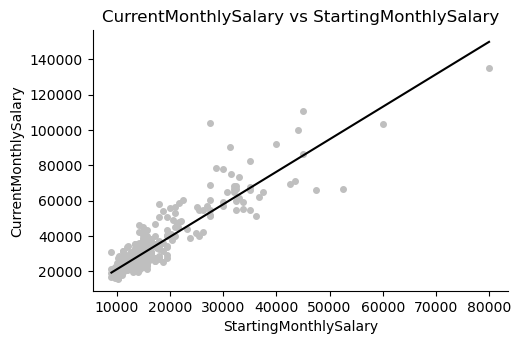

StartingMonthlySalary:
  Pearson r     : 0.9022  (strong positive correlation)
  P-value       : 0.000000  (significant at α = 0.05)
  Slope (m)     : 1.8393
  Intercept (k) : 2752.5574
  R²            : 0.8139  (81.4% of salary variation explained)
  → Employees who started on higher salaries continue to earn significantly more — starting salary is the strongest individual predictor of current salary.



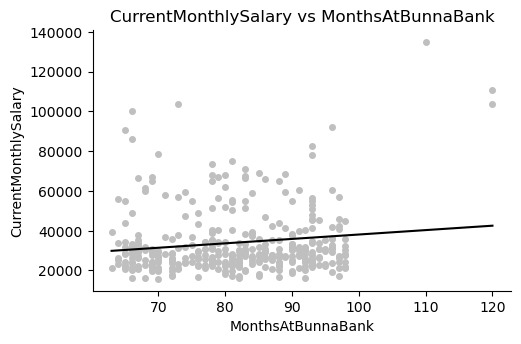

MonthsAtBunnaBank:
  Pearson r     : 0.1406  (weak positive correlation)
  P-value       : 0.006462  (significant at α = 0.05)
  Slope (m)     : 221.9945
  Intercept (k) : 15866.7377
  R²            : 0.0198  (2.0% of salary variation explained)
  → Tenure at Bunna Bank has a weak but statistically significant positive relationship with current salary.



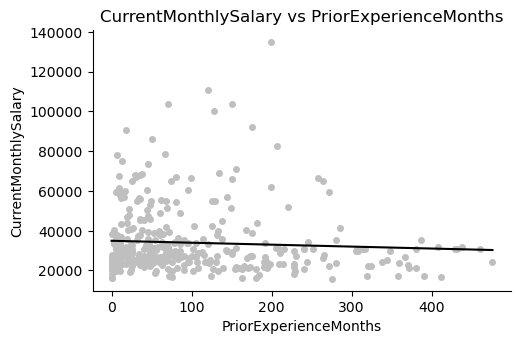

PriorExperienceMonths:
  Pearson r     : -0.0610  (weak negative correlation)
  P-value       : 0.239388  (not significant at α = 0.05)
  Slope (m)     : -9.7632
  Intercept (k) : 34914.3065
  R²            : 0.0037  (0.4% of salary variation explained)
  → Prior experience shows no statistically significant relationship with current salary.



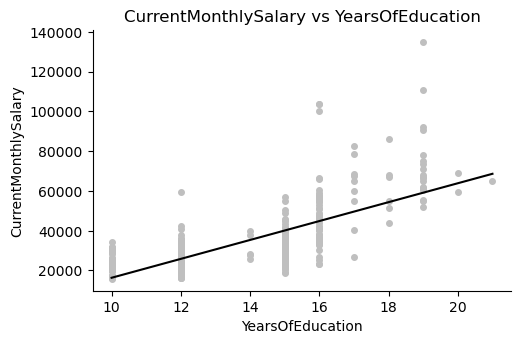

YearsOfEducation:
  Pearson r     : 0.6964  (strong positive correlation)
  P-value       : 0.000000  (significant at α = 0.05)
  Slope (m)     : 4756.2017
  Intercept (k) : -31261.2090
  R²            : 0.4849  (48.5% of salary variation explained)
  → More educated employees tend to earn significantly more, with education explaining nearly half of the salary variation on its own.



In [104]:
interpretations = {
    'StartingMonthlySalary': 'Employees who started on higher salaries continue to earn significantly more — starting salary is the strongest individual predictor of current salary.',
    'MonthsAtBunnaBank': 'Tenure at Bunna Bank has a weak but statistically significant positive relationship with current salary.',
    'PriorExperienceMonths': 'Prior experience shows no statistically significant relationship with current salary.',
    'YearsOfEducation': 'More educated employees tend to earn significantly more, with education explaining nearly half of the salary variation on its own.'
}
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.formula.api import ols

x_vars = ['StartingMonthlySalary', 'MonthsAtBunnaBank', 'PriorExperienceMonths', 'YearsOfEducation']
y_var = 'CurrentMonthlySalary'

for x_var in x_vars:
    x = df[x_var].values
    y = df[y_var].values

    # Pearson correlation and significance test
    r, p_val = pearsonr(x, y)

    # Fit regression line using statsmodels OLS
    model = ols(f'{y_var} ~ {x_var}', data=df).fit()
    m = model.params[x_var]
    k = model.params['Intercept']
    r_squared = model.rsquared

    # Scatter plot with fitted line
    fig, ax = plt.subplots(figsize=(9/2.54 * 1.5, 9/2.54))
    ax.plot(x, y, linestyle='none', marker='o', markersize=4, color=[0.75, 0.75, 0.75])
    x_line = np.linspace(np.min(x), np.max(x), 200)
    ax.plot(x_line, m * x_line + k, '-', color='black')
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f'{y_var} vs {x_var}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Results summary
    direction = 'positive' if r > 0 else 'negative'
    strength = 'strong' if abs(r) > 0.5 else ('moderate' if abs(r) > 0.3 else 'weak')
    sig = 'significant' if p_val < 0.05 else 'not significant'
    print(f'{x_var}:')
    print(f'  Pearson r     : {r:.4f}  ({strength} {direction} correlation)')
    print(f'  P-value       : {p_val:.6f}  ({sig} at α = 0.05)')
    print(f'  Slope (m)     : {m:.4f}')
    print(f'  Intercept (k) : {k:.4f}')
    print(f'  R²            : {r_squared:.4f}  ({r_squared*100:.1f}% of salary variation explained)')
    print(f'  → {interpretations[x_var]}')
    print()

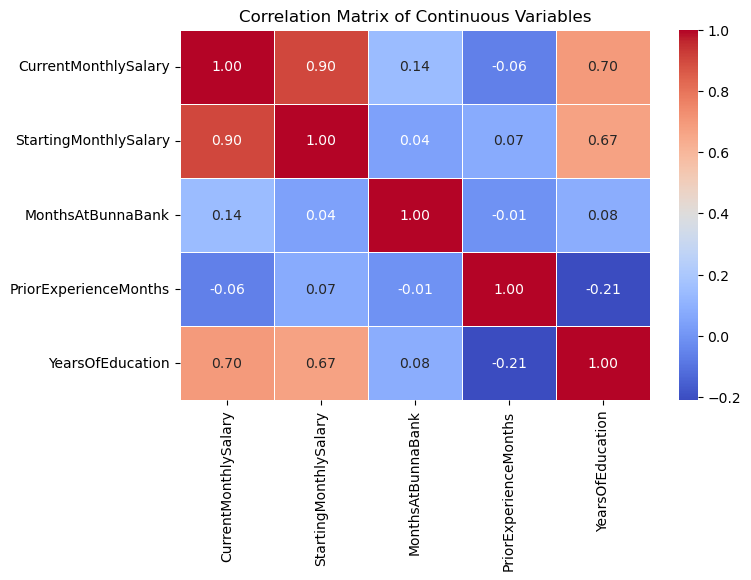

Correlations with CurrentMonthlySalary (strongest to weakest):
CurrentMonthlySalary     1.000000
StartingMonthlySalary    0.902167
YearsOfEducation         0.696370
MonthsAtBunnaBank        0.140592
PriorExperienceMonths   -0.060984
Name: CurrentMonthlySalary, dtype: float64


In [105]:
import seaborn as sns

# Correlation matrix of all continuous variables including the target
cont_cols = ['CurrentMonthlySalary', 'StartingMonthlySalary', 'MonthsAtBunnaBank',
             'PriorExperienceMonths', 'YearsOfEducation']
corr_matrix = df[cont_cols].corr()

fig, ax = plt.subplots(figsize=(10/2.54 * 2, 10/2.54 * 1.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix of Continuous Variables')
plt.tight_layout()
plt.show()

print('Correlations with CurrentMonthlySalary (strongest to weakest):')
print(corr_matrix['CurrentMonthlySalary'].sort_values(ascending=False))

`StartingMonthlySalary` has the strongest correlation with current salary (r = 0.90), followed by `YearsOfEducation` (r = 0.70). `MonthsAtBunnaBank` shows a very weak positive correlation (r = 0.14), while `PriorExperienceMonths` has a negligible negative correlation (r = -0.06), meaning prior experience outside Bunna Bank has almost no relationship with current salary.

## Section 6 — Linear Regression Model (Multi Variable)

We now fit a multi-variable linear regression model using all available predictors. Unlike Section 5 where each variable was tested on its own, this model controls for all variables simultaneously, so each coefficient shows the effect of that variable *holding all others constant*.

**Target (y):** `CurrentMonthlySalary`  
**Predictors (x):** `Sex_num`, `YearsOfEducation`, `StartingMonthlySalary`, `MonthsAtBunnaBank`, `PriorExperienceMonths`

For each predictor we read the t-statistic and p-value from the model summary to determine whether its coefficient is significantly different from zero (α = 0.05).

In [106]:
from statsmodels.formula.api import ols

# Sex_num was already encoded in Section 2 (f=0, m=1)
formula = ('CurrentMonthlySalary ~ Sex_num + YearsOfEducation + '
           'StartingMonthlySalary + MonthsAtBunnaBank + PriorExperienceMonths')
model_multi = ols(formula, data=df).fit()
print(model_multi.summary())

                             OLS Regression Results                             
Dep. Variable:     CurrentMonthlySalary   R-squared:                       0.849
Model:                              OLS   Adj. R-squared:                  0.847
Method:                   Least Squares   F-statistic:                     413.5
Date:                  Sat, 02 May 2026   Prob (F-statistic):          1.41e-148
Time:                          13:26:45   Log-Likelihood:                -3812.1
No. Observations:                   374   AIC:                             7636.
Df Residuals:                       368   BIC:                             7660.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept 

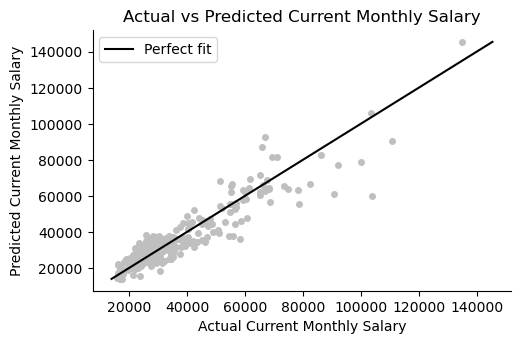

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Actual vs predicted salary scatter plot
predicted = model_multi.fittedvalues
actual = df['CurrentMonthlySalary']

fig, ax = plt.subplots(figsize=(9/2.54 * 1.5, 9/2.54))
ax.plot(actual, predicted, linestyle='none', marker='o', markersize=4, color=[0.75, 0.75, 0.75])
min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())
ax.plot([min_val, max_val], [min_val, max_val], '-', color='black', label='Perfect fit')
ax.set_xlabel('Actual Current Monthly Salary')
ax.set_ylabel('Predicted Current Monthly Salary')
ax.set_title('Actual vs Predicted Current Monthly Salary')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The multi-variable regression model explains 84.9% of salary variation (R² = 0.85), meaning the five factors together give a strong prediction of current salary. All five factors are statistically significant: `StartingMonthlySalary` is the dominant predictor, followed by `PriorExperienceMonths`, `MonthsAtBunnaBank`, `YearsOfEducation`, and `Sex`. Notably, `PriorExperienceMonths` has a negative coefficient, meaning more prior experience outside Bunna Bank is associated with slightly lower current salary when other factors are held constant. The actual vs predicted plot shows that most predictions follow the perfect fit line closely, though the model tends to underestimate some of the higher salaries.

## Section 7 — Discussion


**Uni-variable vs multi-variable**
- `StartingMonthlySalary` alone explains most of the salary variation; the other factors add only a small improvement when combined
- `MonthsAtBunnaBank` and `PriorExperienceMonths` are weak individually but become significant when other factors are controlled for
- Part of `YearsOfEducation`'s effect is shared with `StartingMonthlySalary`, as more educated employees tend to start on higher salaries

**Gender and salary**
- At Bunna Bank, male and female employees are hired with the same salary for the same position. However, the data shows male employees currently earn more, even after accounting for all other factors. This gap may be partly explained by differences in promotion opportunities, though this would need to be verified with further data and research in the future

**Strongest predictor**
- `StartingMonthlySalary` is the strongest independent predictor, salary is largely set at hiring and carries forward

## Section 8 — Conclusion

The analysis of Bunna Bank employees shows that `StartingMonthlySalary` is by far the strongest predictor of current salary, meaning salary is largely determined at the point of hiring. When all available factors are combined in a single model, they together explain the salary differences well, and each factor has a statistically significant contribution.

Gender does play a significant role. Even after controlling for education, experience, tenure, and starting salary, male employees earn more than female employees. This gap may be partly explained by differences in promotion opportunities, though this would need to be verified with further data and research in the future.

**Limitations**
- This analysis is based on a sample, not the full workforce, so the findings may not represent all Bunna Bank employees
- The data is a snapshot at one point in time, it does not show how salaries change over time
- The analysis shows associations between factors and salary, but cannot prove that one factor causes another